### Logistic regression with multiple feature


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay

### 1. Data Retrieval and Collection


In [3]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df

In [4]:
df = load_data(filepath='Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [5]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [6]:
df.shape

(270, 14)

### 2. Data Cleaning


In [7]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
dtype: object

### 3. Feature Design

In [10]:
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
df[['Heart Disease']] = encoder.fit_transform(df[['Heart Disease']]).astype(int)
df['Heart Disease'].head(2)

0    1
1    0
Name: Heart Disease, dtype: int64

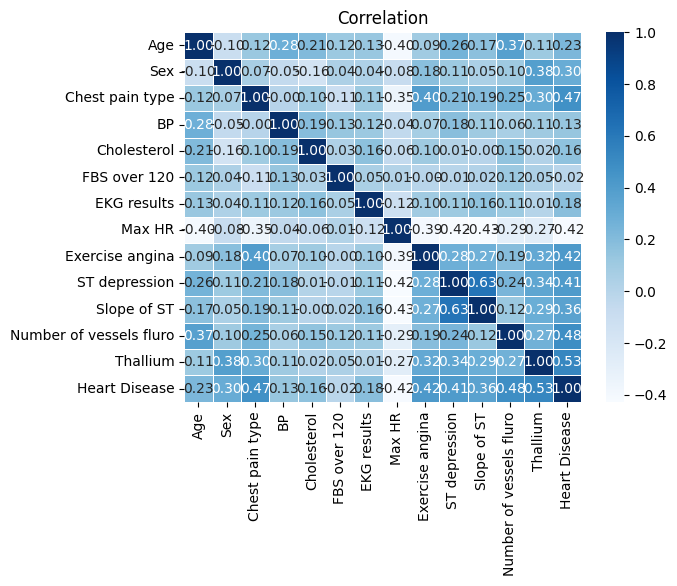

In [11]:
sns.heatmap(df.corr(method="spearman"), annot=True, cmap="Blues",linewidths=.5,fmt=".2f")
plt.title("Correlation")
plt.show()

In [12]:
feature = df[['Age','Sex','Chest pain type','BP','Cholesterol','FBS over 120','EKG results','Max HR',
              'Exercise angina','ST depression','Slope of ST','Number of vessels fluro','Thallium']]
target = df['Heart Disease']

### Using multiple features often leads to:

1. Higher prediction accuracy
2. Better identification of patients at risk
3. Improved precision and recall
4. A more comprehensive understanding of the factors associated with heart disease

### 4. Algorithm Selection
Logistic Regression

Logistic Regression was selected as the classification algorithm because the target variable (HeartDisease) is binary, having two possible outcomes: presence (1) or absence (0) of heart disease. Logistic Regression is simple, efficient, and effective for binary classification problems. It estimates the probability of an instance belonging to a particular class using the sigmoid function.


### 5. Loss Function Selection
Binary Cross-Entropy (Log Loss)

Binary Cross-Entropy, also known as Log Loss, was used as the loss function for Logistic Regression. It measures the difference between the actual class labels and the predicted probabilities. The loss increases when the model makes incorrect predictions with high confidence and decreases when predictions are accurate. Minimizing this loss helps the model improve its classification performance.

### 6. Model Learning(Training)

In [13]:
# split the data
x_train, x_test, y_train, y_test = train_test_split(feature, target , stratify=target, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((202, 13), (68, 13), (202,), (68,))

In [14]:
x_tr_scaled = StandardScaler().fit_transform(x_train)
x_te_scaled = StandardScaler().fit_transform(x_test)
x_tr_scaled, x_te_scaled

(array([[-0.04609286,  0.704483  , -0.10050886, ...,  2.34864408,
          0.38767728, -0.86421337],
        [ 0.83021379, -1.41948067,  0.91463061, ..., -0.98066192,
         -0.71529188, -0.86421337],
        [-0.70332285,  0.704483  , -1.11564832, ...,  0.68399108,
         -0.71529188, -0.86421337],
        ...,
        [-1.47009118,  0.704483  , -1.11564832, ...,  0.68399108,
         -0.71529188,  0.68983204],
        [-0.26516953,  0.704483  , -1.11564832, ..., -0.98066192,
          0.38767728, -0.86421337],
        [-0.26516953,  0.704483  ,  0.91463061, ..., -0.98066192,
          0.38767728, -0.86421337]], shape=(202, 13)),
 array([[-1.72256372,  0.64549722,  0.76465394, -0.66370447, -0.7160325 ,
         -0.46291005, -0.90862787, -0.29378281, -0.81150267,  0.10032273,
          0.65722643, -0.70852525,  1.13630232],
        [ 0.28163589,  0.64549722,  0.76465394,  1.17180358,  0.40071543,
         -0.46291005, -0.90862787, -2.3386962 ,  1.23228183,  0.10032273,
          0

In [15]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(penalty=None, random_state=42)
logistic_model.fit(x_tr_scaled, y_train)

c:\Users\HP\Desktop\AI\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver becaus

In [16]:
logistic_model.coef_

array([[-0.02218123,  1.04705827,  0.75575151,  0.43959406,  0.39699968,
        -0.42473305,  0.01222346, -0.42156472,  0.49165767,  0.23232654,
         0.5367364 ,  1.25632425,  0.52343446]])

### 7. Model Evaluation

In [17]:
y_pred = logistic_model.predict(x_te_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88        38
           1       0.84      0.87      0.85        30

    accuracy                           0.87        68
   macro avg       0.87      0.87      0.87        68
weighted avg       0.87      0.87      0.87        68



Confusion Matrix
[[33  5]
 [ 4 26]]


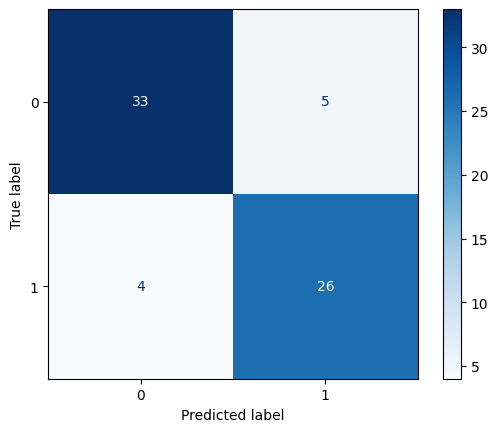

In [18]:
print("Confusion Matrix")
confusion_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
ConfusionMatrixDisplay(confusion_matrix=confusion_mat).plot(cmap="Blues")
print(confusion_mat)

In [19]:
y_score = logistic_model.predict_proba(x_te_scaled)[:,1]

Average Precision Score: 0.897


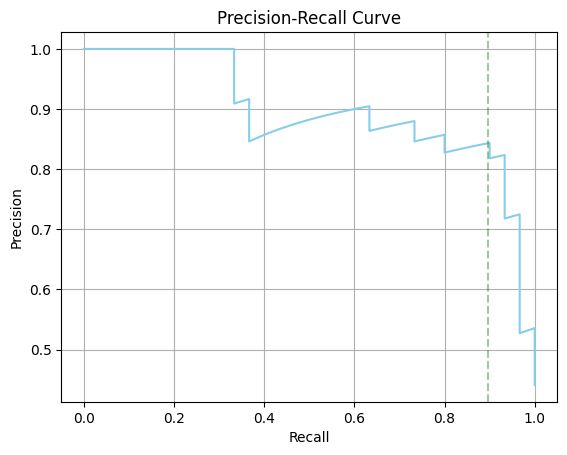

In [20]:
precision, recall, threshold = precision_recall_curve(y_test, y_score)
pr_auc = average_precision_score(y_test, y_score)
plt.plot(recall, precision, color='skyblue')
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axvline(pr_auc, color='g', alpha=0.4, linestyle='--')
print(f"Average Precision Score: {pr_auc:.3f}")